# Load Type Prediction — Power System Classification

**Objective:** Predict the Load_Type (Light Load, Medium Load, Maximum Load) of a power system from historical sensor readings.

**STEPS followed:**
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing & Feature Engineering
3. Temporal Train/Test Split (last month = test set)
4. Model Selection & Training (Logistic Regression → Random Forest → XGBoost)
5. Evaluation (Accuracy, Precision, Recall, F1)
6. Insights & Conclusions

## 1. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Data

In [4]:
df = pd.read_csv('load_data.csv', parse_dates=['Date_Time'], dayfirst=True)
df = df.sort_values('Date_Time').reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.Date_Time.min()}  →  {df.Date_Time.max()}')
df.head()

Dataset shape: (35041, 9)
Date range: 2018-01-01 00:00:00  →  2018-12-31 23:45:00


,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,2018-01-01 00:00:00,3.420000,3.46,0.0,0.0,70.30,291.49819,0.000000,Light_Load
1,2018-01-01 00:15:00,8.753692,2.95,0.0,0.0,73.21,100.00000,900.000000,Light_Load
2,2018-01-01 00:30:00,4.000000,4.46,0.0,0.0,66.77,100.00000,1800.000000,Light_Load
3,2018-01-01 00:45:00,3.240000,3.28,0.0,0.0,70.28,100.00000,8070.880991,Light_Load
4,2018-01-01 01:00:00,3.310000,3.56,0.0,0.0,68.09,100.00000,3600.000000,Light_Load


## 3. Exploratory Data Analysis (EDA)

In [5]:
# ── Basic statistics
df.describe()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35041,33482.000000,34165.000000,33885.000000,34586.000000,34691.000000,33570.000000,34586.000000
mean,2018-07-02 11:59:59.589052928,30.873061,14.704573,4.386097,0.012947,90.740871,94.926552,48013.664032
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-04-02 06:00:00,3.310000,2.340000,0.000000,0.000000,66.295000,99.800000,22500.000000
50%,2018-07-02 12:00:00,5.290000,5.180000,0.000000,0.000000,90.080000,100.000000,45000.000000
75%,2018-10-01 18:00:00,53.560000,23.510000,2.298558,0.020000,100.000000,100.000000,68400.000000
max,2018-12-31 23:45:00,435.019069,262.630718,78.809000,0.188166,299.996814,299.969494,248821.810465
std,NaN,41.415015,20.342721,9.090181,0.019726,39.745395,49.826872,34046.492333


In [6]:
# ── Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
Date_Time,0,0.00
Usage_kWh,1559,4.45
Lagging_Current_Reactive.Power_kVarh,876,2.50
Leading_Current_Reactive_Power_kVarh,1156,3.30
CO2(tCO2),455,1.30
Lagging_Current_Power_Factor,350,1.00
Leading_Current_Power_Factor,1471,4.20
NSM,455,1.30
Load_Type,0,0.00


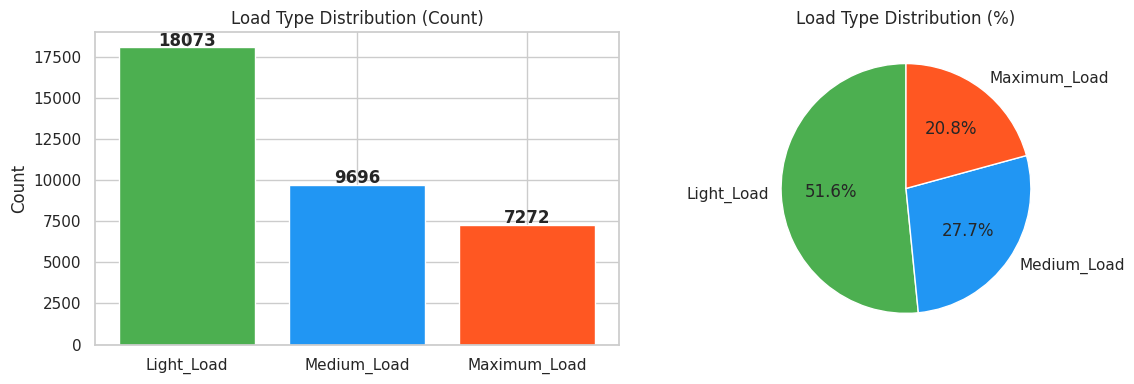

Class imbalance note: Light_Load dominates (~51.6%). We will use class_weight="balanced" where applicable.


In [7]:
# ── Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Load_Type'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50', '#2196F3', '#FF5722'])
axes[0].set_title('Load Type Distribution (Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#2196F3', '#FF5722'], startangle=90)
axes[1].set_title('Load Type Distribution (%)')

plt.tight_layout()
plt.show()
print('Class imbalance note: Light_Load dominates (~51.6%). We will use class_weight="balanced" where applicable.')

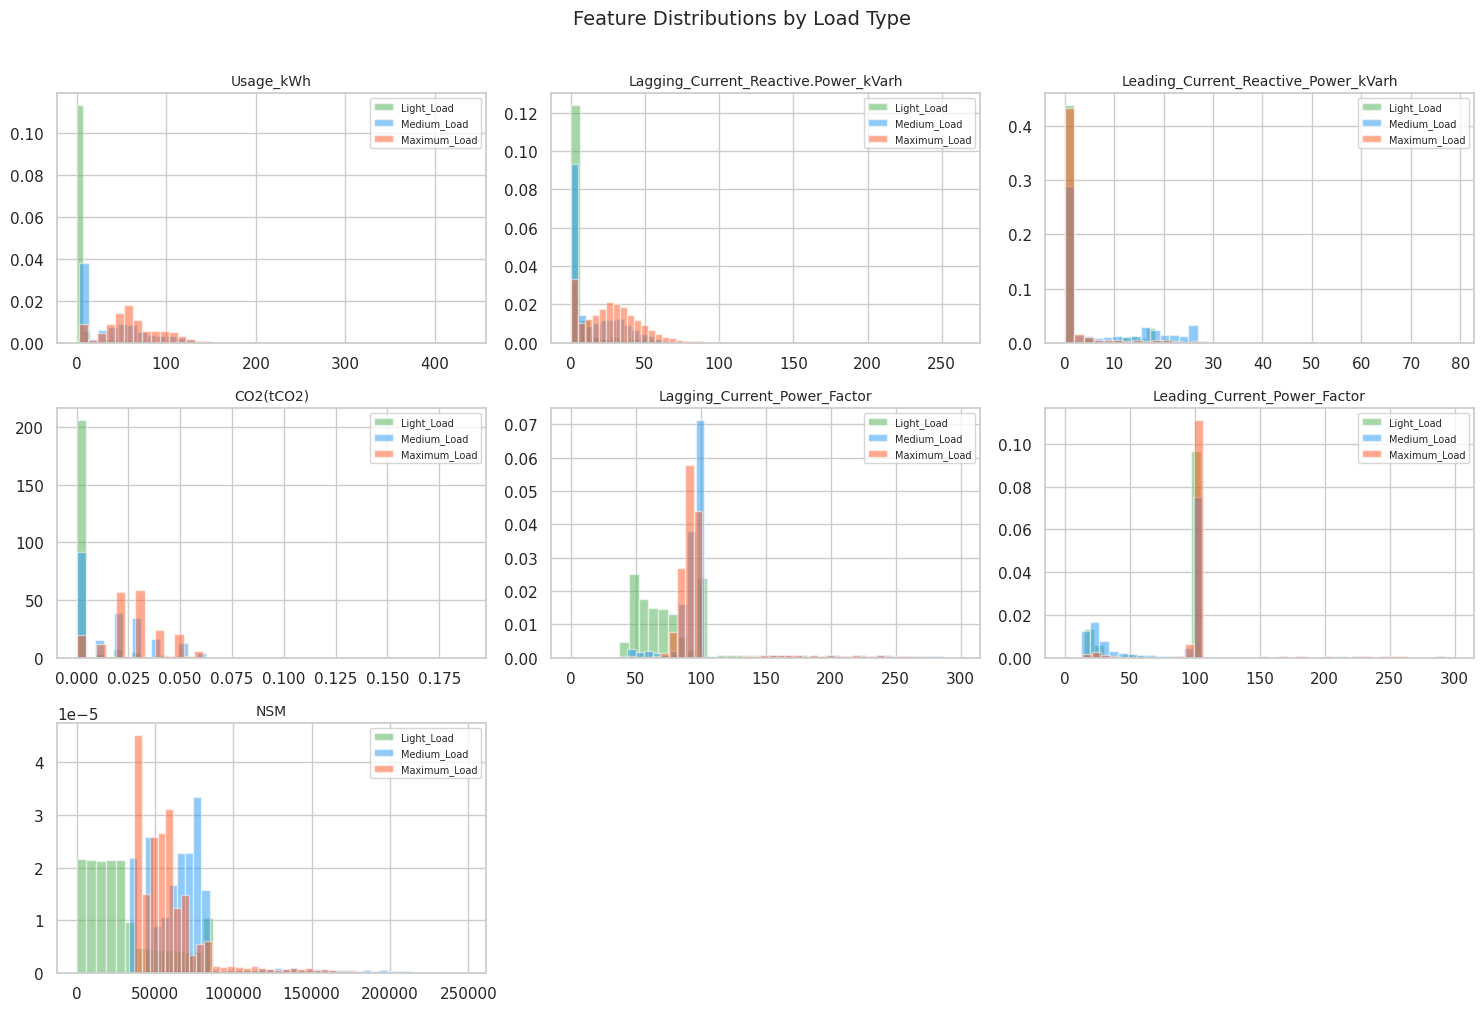

In [8]:
# ── Feature distributions by Load Type
numeric_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
                'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
                'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
colors = {'Light_Load': '#4CAF50', 'Medium_Load': '#2196F3', 'Maximum_Load': '#FF5722'}

for i, col in enumerate(numeric_cols):
    for load_type, color in colors.items():
        subset = df[df['Load_Type'] == load_type][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, label=load_type, color=color, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature Distributions by Load Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

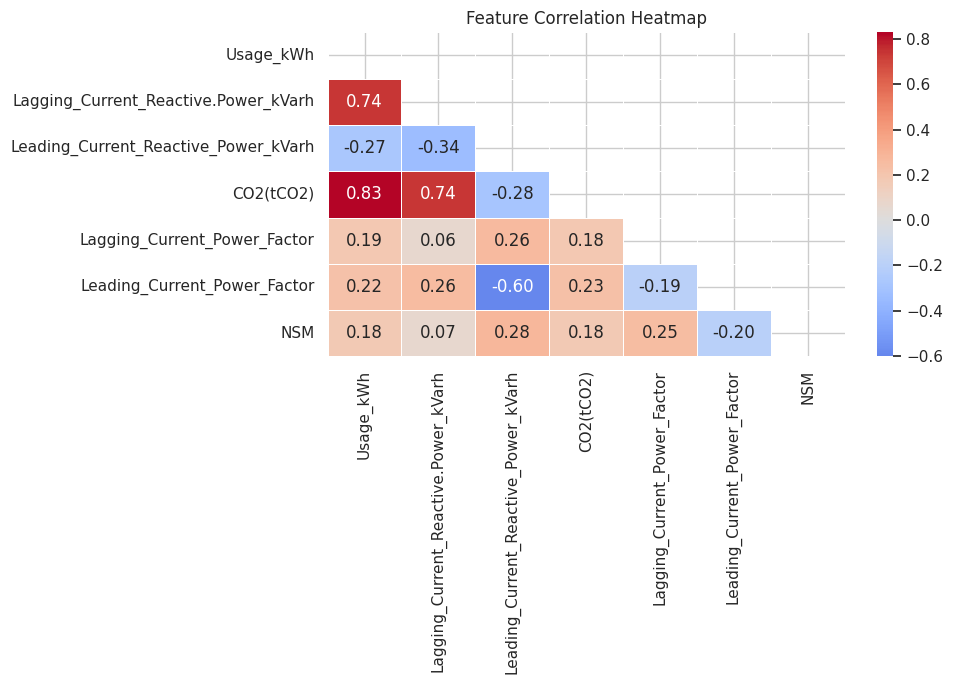

In [9]:
# ── Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

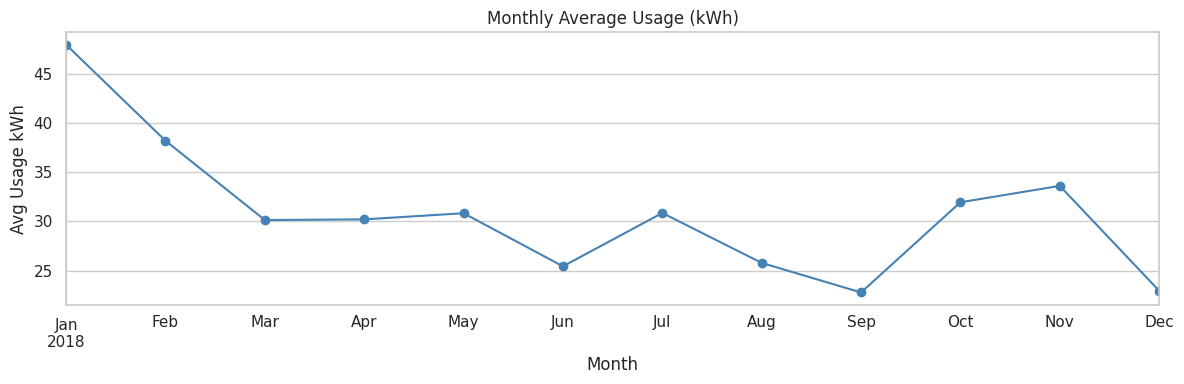

In [10]:
# ── Usage_kWh over time (monthly trend)
monthly = df.set_index('Date_Time').resample('ME')['Usage_kWh'].mean()
plt.figure(figsize=(12, 4))
monthly.plot(marker='o', color='steelblue')
plt.title('Monthly Average Usage (kWh)')
plt.ylabel('Avg Usage kWh')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [11]:
df_fe = df.copy()

# ── Time-based features
df_fe['hour']         = df_fe['Date_Time'].dt.hour
df_fe['day_of_week']  = df_fe['Date_Time'].dt.dayofweek   # 0=Mon, 6=Sun
df_fe['month']        = df_fe['Date_Time'].dt.month
df_fe['is_weekend']   = (df_fe['day_of_week'] >= 5).astype(int)

# Cyclical encoding for hour and month (preserves circular continuity)
df_fe['hour_sin']     = np.sin(2 * np.pi * df_fe['hour'] / 24)
df_fe['hour_cos']     = np.cos(2 * np.pi * df_fe['hour'] / 24)
df_fe['month_sin']    = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos']    = np.cos(2 * np.pi * df_fe['month'] / 12)

# ── Domain-specific features
# Apparent power (S) from active and reactive components
df_fe['apparent_power'] = np.sqrt(
    df_fe['Usage_kWh']**2 +
    df_fe['Lagging_Current_Reactive.Power_kVarh']**2
)

# Total reactive power
df_fe['total_reactive_power'] = (
    df_fe['Lagging_Current_Reactive.Power_kVarh'] +
    df_fe['Leading_Current_Reactive_Power_kVarh']
)

# Power factor ratio (lagging vs leading)
df_fe['pf_ratio'] = (
    df_fe['Lagging_Current_Power_Factor'] /
    (df_fe['Leading_Current_Power_Factor'] + 1e-6)
)

print('Feature engineering done.')
print(f'New shape: {df_fe.shape}')
df_fe[['apparent_power', 'total_reactive_power', 'pf_ratio',
        'hour_sin', 'hour_cos', 'is_weekend']].head()

Feature engineering done.
New shape: (35041, 20)


,apparent_power,total_reactive_power,pf_ratio,hour_sin,hour_cos,is_weekend
0,4.864977,3.46,0.241168,0.000000,1.000000,0
1,9.237404,2.95,0.732100,0.000000,1.000000,0
2,5.990960,4.46,0.667700,0.000000,1.000000,0
3,4.610423,3.28,0.702800,0.000000,1.000000,0
4,4.861039,3.56,0.680900,0.258819,0.965926,0


## 5. Preprocessing & Train/Test Split

In [12]:
# ── Feature list
FEATURE_COLS = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM',
    # engineered
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_weekend', 'apparent_power', 'total_reactive_power', 'pf_ratio'
]
TARGET = 'Load_Type'

# ── Impute missing values (median per column — robust to outliers)
for col in FEATURE_COLS:
    if df_fe[col].isnull().any():
        median_val = df_fe[col].median()
        df_fe[col] = df_fe[col].fillna(median_val)

# ── Encode target
le = LabelEncoder()
df_fe['target'] = le.fit_transform(df_fe[TARGET])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# ── Temporal split: last month (December 2018) = test set
cutoff = df_fe['Date_Time'].max() - pd.DateOffset(months=1)
train_df = df_fe[df_fe['Date_Time'] <= cutoff]
test_df  = df_fe[df_fe['Date_Time'] >  cutoff]

X_train = train_df[FEATURE_COLS].values
y_train = train_df['target'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['target'].values

print(f'\nTrain size: {X_train.shape[0]} rows  ({train_df.Date_Time.min().date()} → {train_df.Date_Time.max().date()})')
print(f'Test size : {X_test.shape[0]} rows  ({test_df.Date_Time.min().date()} → {test_df.Date_Time.max().date()})')

Label mapping: {'Light_Load': np.int64(0), 'Maximum_Load': np.int64(1), 'Medium_Load': np.int64(2)}

Train size: 32064 rows  (2018-01-01 → 2018-11-30)
Test size : 2977 rows  (2018-12-01 → 2018-12-31)


## 6. Model Training & Evaluation

In [13]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    """Train, predict and return a metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    metrics = {
        'Model': model_name,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score':  round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
    }
    return metrics, y_pred

results = []
predictions = {}

In [14]:
# ── Logistic Regression (with scaling)
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
m, p = evaluate_model(lr_pipe, X_train, y_train, X_test, y_test, 'Logistic Regression')
results.append(m)
predictions['Logistic Regression'] = p
print('Logistic Regression:', m)

Logistic Regression: {'Model': 'Logistic Regression', 'Accuracy': 0.6335, 'Precision': 0.6834, 'Recall': 0.6335, 'F1-Score': 0.6546}


In [15]:
# ── Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
m, p = evaluate_model(rf, X_train, y_train, X_test, y_test, 'Random Forest')
results.append(m)
predictions['Random Forest'] = p
print('Random Forest:', m)

Random Forest: {'Model': 'Random Forest', 'Accuracy': 0.9459, 'Precision': 0.9482, 'Recall': 0.9459, 'F1-Score': 0.9463}


In [16]:
# ── XGBoost
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
)
m, p = evaluate_model(xgb, X_train, y_train, X_test, y_test, 'XGBoost')
results.append(m)
predictions['XGBoost'] = p
print('XGBoost:', m)

XGBoost: {'Model': 'XGBoost', 'Accuracy': 0.9402, 'Precision': 0.9448, 'Recall': 0.9402, 'F1-Score': 0.9407}


## 7. Results Comparison

In [17]:
results_df = pd.DataFrame(results).set_index('Model')
results_df.style.highlight_max(color='lightgreen').format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.6335,0.6834,0.6335,0.6546
Random Forest,0.9459,0.9482,0.9459,0.9463
XGBoost,0.9402,0.9448,0.9402,0.9407


In [19]:
# ── Best model: detailed classification report & confusion matrix
best_model_name = results_df['F1-Score'].idxmax()
best_preds = predictions[best_model_name]

print(f'=== Best Model: {best_model_name} ===')
print()
print(classification_report(y_test, best_preds, target_names=le.classes_))

=== Best Model: Random Forest ===

              precision    recall  f1-score   support

  Light_Load       0.98      0.93      0.96      1745
Maximum_Load       0.89      0.95      0.92       528
 Medium_Load       0.91      0.97      0.94       704

    accuracy                           0.95      2977
   macro avg       0.93      0.95      0.94      2977
weighted avg       0.95      0.95      0.95      2977



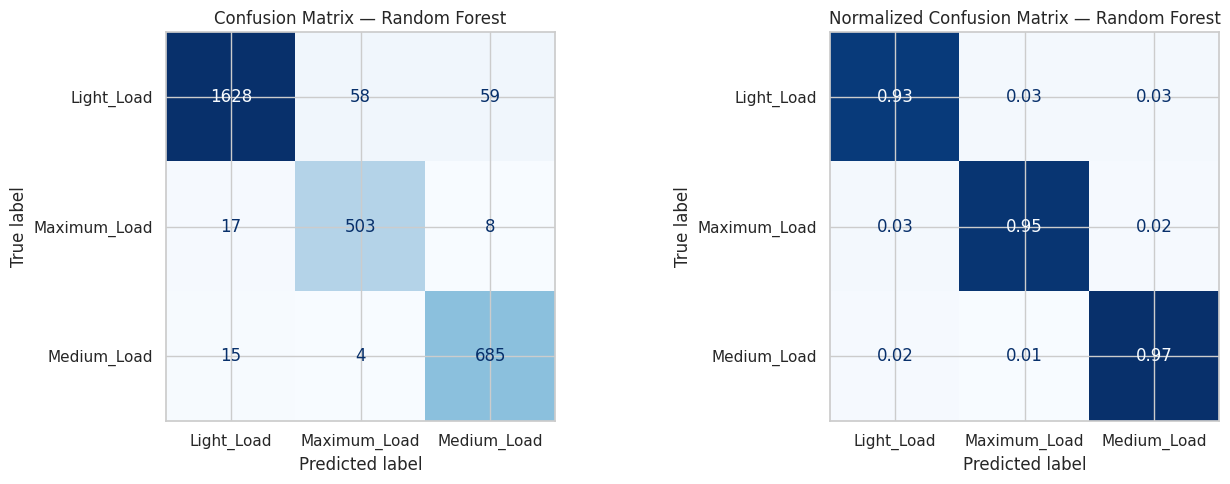

In [20]:
# ── Confusion matrix
cm = confusion_matrix(y_test, best_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_model_name}')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2), display_labels=le.classes_)
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Normalized Confusion Matrix — {best_model_name}')

plt.tight_layout()
plt.show()

## 8. Feature Importance (Best Model)

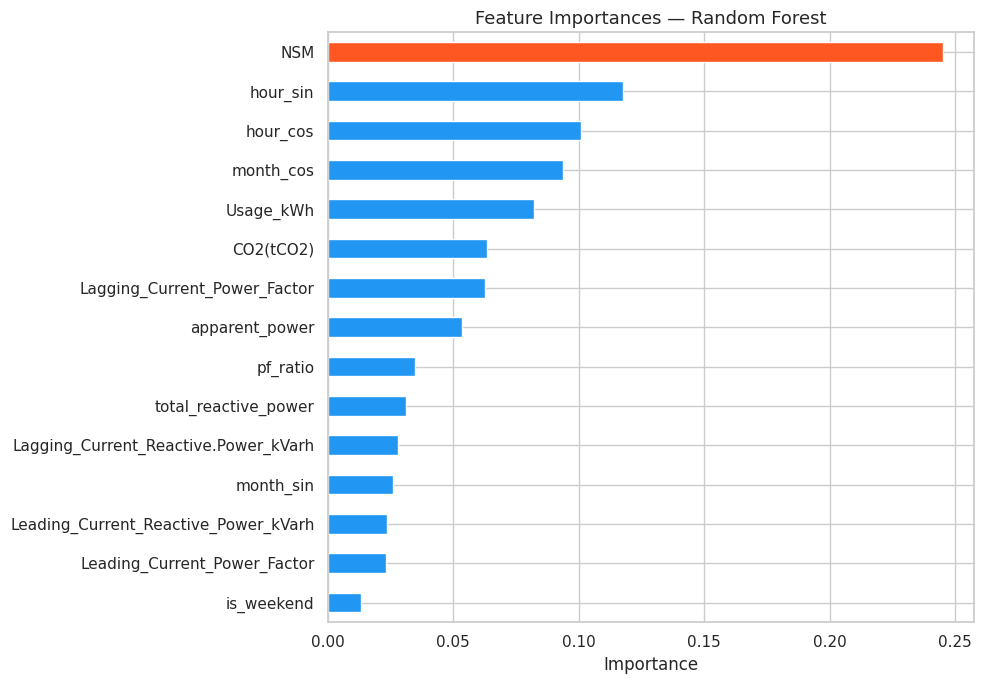

Top 5 most important features:
NSM          0.245305
hour_sin     0.117746
hour_cos     0.100854
month_cos    0.093842
Usage_kWh    0.082236
dtype: float64


In [21]:
# Use XGBoost feature importances (or Random Forest if XGBoost not best)
if best_model_name == 'XGBoost':
    importances = xgb.feature_importances_
elif best_model_name == 'Random Forest':
    importances = rf.feature_importances_
else:
    # Logistic regression: use absolute coefficients (mean across classes)
    scaler = lr_pipe.named_steps['scaler']
    importances = np.abs(lr_pipe.named_steps['clf'].coef_).mean(axis=0)

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_bar = ['#FF5722' if v == feat_imp.max() else '#2196F3' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors_bar[::-1][::-1])
plt.title(f'Feature Importances — {best_model_name}', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_imp.sort_values(ascending=False).head())